In [30]:
'''
Homework 2
Questo homework ha l’obiettivo di affrontare un problema di classificazione, 
cercando di ottenere le migliori prestazioni possibili, utilizzando i modelli e le metodologie viste a lezione. 
Il dataset da utilizzare è CIFAR10: contiene 60,000 immagini (50,000 di training e 10,000 di test) divise in 10 classi, 
a risoluzione 32x32 pixel, a colori. Questa è la pagina di riferimento del dataset.

Nello specifico, i requisiti dell’homework sono:

caricare correttamente il dataset CIFAR10;
utilizzare i seguenti modelli di classificazione: regressione logistica, k-NN, SVM, decision tree;
effettuare opportunamente la model selection;
riportare le prestazioni ottenuti, secondo le metriche di valutazione appropriate.
La strategia di esecuzione di ciascuna di queste fasi è a scelta dello studente. La valutazione dell’homework terrà conto della correttezza metodologica, della correttezza dell’implementazione e della completezza dell’approccio di ricerca del modello migliore.

Nel caso in cui l’allenamento dei modelli risulti eccessivamente dispensioso in termini di tempo, è possibile valutare l’ipotesi di sotto-campionamento del dataset.

Consegna
La consegna del MHW dovrà essere effettuata su GitHub, in un repository chiamato esattamente hw2, e dovrà includere:

il notebook contenente la soluzione;
una presentazione in PowerPoint, da esporre in sede di esame, che includa:
descrizione del dataset;
descrizione della metodologia adottata;
descrizione dei risultati.
'''

'\nHomework 2\nQuesto homework ha l’obiettivo di affrontare un problema di classificazione, \ncercando di ottenere le migliori prestazioni possibili, utilizzando i modelli e le metodologie viste a lezione. \nIl dataset da utilizzare è CIFAR10: contiene 60,000 immagini (50,000 di training e 10,000 di test) divise in 10 classi, \na risoluzione 32x32 pixel, a colori. Questa è la pagina di riferimento del dataset.\n\nNello specifico, i requisiti dell’homework sono:\n\ncaricare correttamente il dataset CIFAR10;\nutilizzare i seguenti modelli di classificazione: regressione logistica, k-NN, SVM, decision tree;\neffettuare opportunamente la model selection;\nriportare le prestazioni ottenuti, secondo le metriche di valutazione appropriate.\nLa strategia di esecuzione di ciascuna di queste fasi è a scelta dello studente. La valutazione dell’homework terrà conto della correttezza metodologica, della correttezza dell’implementazione e della completezza dell’approccio di ricerca del modello migli

In [31]:
#importazione delle librerie e delle classi necessarie
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

import warnings
warnings.filterwarnings("ignore")

In [32]:
#fase di importazione del dataset
import pickle
import numpy as np
import os

# Funzione per caricare un batch-file (ce ne sono 5 totali)
def load_cifar10_batch(file_path):
    with open(file_path, 'rb') as f:
        batch = pickle.load(f, encoding='latin1')
        X = batch['data']          # immagini in forma piatta
        y = batch['labels']        # etichette
        return X, y

# Percorso del dataset all'interno di kaggle
data_dir = '/kaggle/input/cifar-10/cifar-10-batches-py' 

# Liste che serviranno ad appendere i dati estratti dai vari batch-file
X_train = []
y_train = []

#richiamo load_cifar10_batch 5 volte per caricare tutti e 5 i batch
for i in range(1, 6):  
    file = os.path.join(data_dir, f'data_batch_{i}')
    X_batch, y_batch = load_cifar10_batch(file)
    X_train.append(X_batch)
    y_train.append(y_batch)

# Creazione del dataset di train
X_train = np.vstack(X_train)
y_train = np.hstack(y_train)

# Caricamento del batch di test
X_test, y_test = load_cifar10_batch(os.path.join(data_dir, 'test_batch'))

# Conversione di y_test e y_train in array NumPy 
y_train = np.array(y_train)
y_test = np.array(y_test)

# Verifico che il dataset sia stato caricato correttamente
print(X_train.shape) #(50000, 3072) nelle righe le osservazioni, nelle colonne le features di train
print(y_train.shape) #(50000,) le labels di ogni classificazione del train set
print(X_test.shape)  #(10000, 3072) nelle righe le osservazioni, nelle colonne le features di test
print(y_test.shape)  #(10000,) le labels di ogni classificazione del test set

(50000, 3072)
(50000,)
(10000, 3072)
(10000,)


In [33]:
# Shuffle del dataset di training
perm = np.random.permutation(len(X_train))  # genera una permutazione casuale degli indici
X_train = X_train[perm]
y_train= y_train[perm]

#riduzione del dataset
X_train_reduced=X_train[:10000]
y_train_reduced=y_train[:10000]
X_test_reduced=X_test[:2000]
y_test_reduced=y_test[:2000]

#standardizzazione dataset ridotto
SC=StandardScaler()
X_train_reduced=SC.fit_transform(X_train_reduced)
X_test_reduced=SC.transform(X_test_reduced)

In [34]:
#funzione per allenamento e scelta delle configurazioni migliori
def train_modello(modello, parametri, X_train, y_train):
    GSCV=GridSearchCV(modello, parametri, scoring='accuracy')
    GSCV.fit(X_train, y_train)
    miglior_configurazione=GSCV.best_params_
    miglior_accuracy=GSCV.best_score_
    modello_allenato=GSCV.best_estimator_
    return miglior_configurazione, miglior_accuracy, modello_allenato

In [35]:
#definizioni delle combinazioni di parametri per ogni modello
param_grid_LR={
    'max_iter': [1000],
    'solver': ['lbfgs'], 
    'C': [0.01, 0.1, 1.0]
}

param_grid_SVC={
    'C': [0.01, 0.1, 1.0],
    'kernel':['linear', 'poly', 'rbf']
}

param_grid_KNN={
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'cosine'],
    'n_neighbors': [3,5,7]
}

#parametri per decision tree
param_grid_DT = {
    'max_depth': [5, 7, None],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'criterion': ['entropy']
}

In [36]:
#allenamento SVC
SVC=SVC(kernel='linear', C=0.01)
b_configuration_SVC, b_accuracy_SVC, b_model_SVC=train_modello(SVC, param_grid_SVC, X_train_reduced, y_train_reduced)
print(f"{b_configuration_SVC}, Accuracy: {b_accuracy_SVC:.2f}, Modello: {b_model_SVC}")

{'C': 1.0, 'kernel': 'rbf'}, Accuracy: 0.47, Modello: SVC()


In [37]:
#allenamento LR
LR=LogisticRegression (max_iter=100, solver='liblinear', C=1.0)
b_configuration_LR, b_accuracy_LR, b_model_LR=train_modello(LR, param_grid_LR, X_train_reduced, y_train_reduced)
print(f"{b_configuration_LR}, Accuracy: {b_accuracy_LR:.2f}, Modello: {b_model_LR}")

{'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}, Accuracy: 0.37, Modello: LogisticRegression(C=0.01, max_iter=1000)


In [38]:
#allenamento KNN
KNN=KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean')
b_configuration_KNN, b_accuracy_KNN, b_model_KNN=train_modello(KNN, param_grid_KNN, X_train_reduced, y_train_reduced)
print(f"{b_configuration_KNN}, Accuracy: {b_accuracy_KNN:.2f}, Modello: {b_model_KNN}")

{'metric': 'cosine', 'n_neighbors': 7, 'weights': 'distance'}, Accuracy: 0.37, Modello: KNeighborsClassifier(metric='cosine', n_neighbors=7, weights='distance')


In [39]:
#allenamento DT
DT=DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_split=5, random_state=42, min_samples_leaf=2)
b_configuration_DT, b_accuracy_DT, b_model_DT=train_modello(DT, param_grid_DT, X_train_reduced, y_train_reduced)
print(f"{b_configuration_DT}, Accuracy: {b_accuracy_DT:.2f}, Modello: {b_model_DT}")

{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 5}, Accuracy: 0.26, Modello: DecisionTreeClassifier(criterion='entropy', max_depth=7, min_samples_leaf=4,
                       min_samples_split=5, random_state=42)


In [40]:
model_and_accuracy=[]
model_and_accuracy.append({
    "model": b_model_LR,
    "accuracy": b_accuracy_LR
}
)
model_and_accuracy.append({
    "model": b_model_SVC,
    "accuracy": b_accuracy_SVC
}
)
model_and_accuracy.append({
    "model": b_model_KNN,
    "accuracy": b_accuracy_KNN
}
)
model_and_accuracy.append({
    "model": b_model_DT,
    "accuracy": b_accuracy_DT
}
)

In [41]:
#model selection sulla base della migliore accuracy
migliore = max(model_and_accuracy, key=lambda x: x["accuracy"])
miglior_modello = migliore["model"]
miglior_accuracy = migliore["accuracy"]

print(f'Scelto il modello {miglior_modello} perchè ha la miglior accuracy: {miglior_accuracy:.3f}')

Scelto il modello SVC() perchè ha la miglior accuracy: 0.466


In [42]:
#prestazioni su test set
y_predicted=miglior_modello.predict(X_test_reduced)

accuracy_test=accuracy_score(y_test_reduced, y_predicted)
precision_test=precision_score(y_test_reduced, y_predicted, average='weighted')
recall_test=recall_score(y_test_reduced, y_predicted, average='weighted')
f1_test=f1_score(y_test_reduced, y_predicted, average='weighted')
cm=confusion_matrix(y_test_reduced, y_predicted)
classification_report=classification_report(y_test_reduced, y_predicted)

print('___PRESTAZIONI SU TEST SET___')
print('\n')
print(f'accuracy: {accuracy_test}')
print(f'precision: {precision_test}')
print(f'recall: {recall_test}')
print(f'f1 score: {f1_test}')
print('\n')
print(cm)
print('\n')
print(classification_report)

___PRESTAZIONI SU TEST SET___


accuracy: 0.4785
precision: 0.4742492822609756
recall: 0.4785
f1 score: 0.4750170984657552


[[102   3  13   4   8   3   5   6  36  16]
 [  5 114   3   9   2   4   6   6  18  31]
 [ 22   8  70  12  33  12  23  12   2   1]
 [ 11   8  26  54  12  33  28  13   4  10]
 [  8   7  39  12  71  11  23  15   9   3]
 [  2   4  19  37  21  65  14  14   4   5]
 [  2   5  19  12  27   9 131   4   3   4]
 [  8   6  14  13  17  17  10  91   5  12]
 [ 17  11   2  10   3   2   4   6 150  12]
 [ 14  31   5   6   3   3   8   4  20 109]]


              precision    recall  f1-score   support

           0       0.53      0.52      0.53       196
           1       0.58      0.58      0.58       198
           2       0.33      0.36      0.35       195
           3       0.32      0.27      0.29       199
           4       0.36      0.36      0.36       198
           5       0.41      0.35      0.38       185
           6       0.52      0.61      0.56       216
         

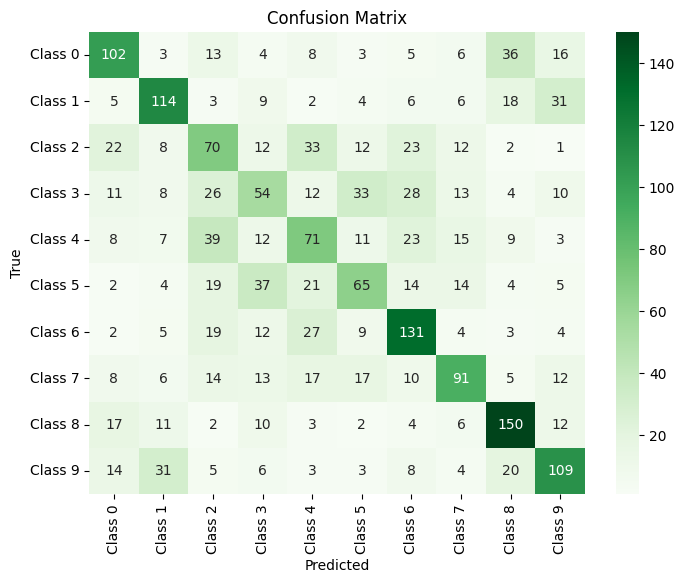

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix_multiclass(cm):
# Calcola dinamicamente le etichette delle classi
    class_labels = [f"Class {i}" for i in range(cm.shape[0])]
    
    # Visualizza la heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix_multiclass(cm)